# Gradient Boosting — Regression

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

and

$$
y_i \in \mathbb{R}
$$

The goal is to learn a function:

$$
f(x)
$$

that minimizes prediction error.

---

## 2. Model Idea

Gradient Boosting builds the model as an additive expansion:

$$
f(x) = f_0(x) + \sum_{m=1}^{M} \gamma_m h_m(x)
$$

where:

- $f_0(x)$ = initial prediction  
- $h_m(x)$ = weak learner (decision tree)  
- $\gamma_m$ = step size  

---

## 3. Initial Prediction

The model starts with a constant prediction:

- For MSE / Huber:

$$
f_0 = \bar{y} = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

- For MAE:

$$
f_0 = \text{median}(y)
$$

---

## 4. Residual Learning

At iteration $m$, compute pseudo-residuals:

### MSE

$$
r_i^{(m)} = y_i - f_{m-1}(x_i)
$$

---

### MAE

$$
r_i^{(m)} = \text{sign}(y_i - f_{m-1}(x_i))
$$

---

### Huber

Let

$$
r_i = y_i - f_{m-1}(x_i)
$$

$$
r_i^{(m)} =
\begin{cases}
r_i & |r_i| \le \delta \\
\delta \cdot \text{sign}(r_i) & |r_i| > \delta
\end{cases}
$$

---

## 5. Base Learner Training

Fit a decision tree on residuals:

$$
h_m(x) \approx r^{(m)}
$$

---

## 6. Step Size (Line Search)

Compute optimal step size:

$$
\gamma_m = \arg\min_{\gamma} \sum_{i=1}^{N}
L\left(y_i, f_{m-1}(x_i) + \gamma h_m(x_i)\right)
$$

For MSE:

$$
\gamma_m = 1
$$

---

## 7. Model Update

Update model:

$$
f_m(x) = f_{m-1}(x) + \eta \gamma_m h_m(x)
$$

where

$$
\eta \in (0,1]
$$

is the learning rate.

---

## 8. Loss Functions

### MSE

$$
L = \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

---

### MAE

$$
L = \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

---

### Huber

$$
L =
\sum_{i=1}^{N}
\begin{cases}
\frac{1}{2}(y_i - \hat{y}_i)^2 & |r_i| \le \delta \\
\delta(|r_i| - \frac{1}{2}\delta) & |r_i| > \delta
\end{cases}
$$

---

## 9. Iterative Optimization

For $m = 1$ to $M$:

1. Compute residuals:

$$
r^{(m)} = - \frac{\partial L}{\partial f_{m-1}}
$$

2. Fit tree:

$$
h_m(x) \approx r^{(m)}
$$

3. Compute step size:

$$
\gamma_m
$$

4. Update model:

$$
f_m(x) = f_{m-1}(x) + \eta \gamma_m h_m(x)
$$

---

## 10. Final Prediction

After $M$ iterations:

$$
\hat{y} = f_0 + \sum_{m=1}^{M} \eta \gamma_m h_m(x)
$$

---

## 11. Interpretation

- Each tree corrects previous errors  
- Sequential learning of residuals  
- Builds complex function from simple models  

---

## 12. Bias–Variance Perspective

- Weak learners → high bias initially  

$$
\text{Bias} \downarrow \text{ as } M \uparrow
$$

- Too many iterations:

$$
\text{Variance} \uparrow
$$

---

## 13. Role of Learning Rate

- Small $\eta$:

$$
\text{Better generalization}
$$

- Large $\eta$:

$$
\text{Faster learning but risk of overfitting}
$$

---

## 14. Connection to Gradient Descent

Gradient Boosting performs optimization in function space:

$$
f_m = f_{m-1} - \eta \nabla L
$$

---

## 15. Final Perspective

Gradient Boosting approximates:

$$
\min_f \sum_{i=1}^{N} L(y_i, f(x_i))
$$

using an additive model of weak learners.

In [1]:
class LeafNode:
    """
    Leaf node of the decision tree.

    Parameters
    ----------
    value : float
        The predicted value at the leaf node (mean or median of targets).
    """
    def __init__(self,value):
        self.value = value

In [2]:
class DecisionNode:
    """
    Internal decision node of the tree.

    Parameters
    ----------
    best_feature : int
        Index of the feature used for splitting.
    best_threshold : float
        Threshold value for the split.
    left_child : Node
        Left subtree (samples satisfying condition).
    right_child : Node
        Right subtree (samples not satisfying condition).
    """
    def __init__(self,best_feature, best_threshold, left_child, right_child):
        self.best_feature = best_feature
        self.best_threshold = best_threshold
        self.left_child = left_child
        self.right_child = right_child

In [3]:
class DecisionTree:
    """
    Decision Tree Regressor supporting MSE, MAE, and Huber loss.

    Parameters
    ----------
    max_depth : int, default=10
        Maximum depth of the tree.

    feature_fraction : float, default=1.0
        Fraction of features randomly selected at each split.

    scoring : str, default='mse'
        Loss function used for splitting.
        Options: 'mse', 'mae', 'huber'

    min_sample_split : int, default=1
        Minimum number of samples required to split.

    delta : float, default=0.5
        Threshold parameter for Huber loss.

    Attributes
    ----------
    root : Node
        Root node of the decision tree.
    """
    def __init__(self, max_depth=1, min_sample_split=1,scoring = 'mse', feature_fraction=1,delta=0.5):
        self.max_depth = max_depth
        self.min_sample_split = min_sample_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction
        self.delta =delta

        self.root = None


        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_sample_split) != int or self.min_sample_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['mse', 'mae','huber']:
            raise ValueError("Scoring must be either 'mse', 'mae' or 'huber'")   
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.delta <= 0:
            raise ValueError("delta must be strictly greater than 0.")

    def _random_feature_sampling(self,data):
        """
        Randomly select a subset of features.

        Returns
        -------
        selected_features : array-like
            Indices of selected features.
        """
        num_feature = data.shape[1]-1
        total_selected_feature = max(1,int(round(num_feature*self.feature_fraction)))
    
        selected_features = np.random.choice(num_feature , total_selected_feature, replace=False)
    
        return selected_features 

    def _stopping_condition(self,data, depth):
        """
        Check whether to stop splitting.

        Stops if:
        - Maximum depth reached
        - Not enough samples
        - Target variance is zero
        """
        if depth >= self.max_depth:
            return True
        if len(data) < self.min_sample_split:
            return True
        if np.var(data[:,-1]) == 0:
            return True
        return False

    def _leaf_value(self, y):
        """
        Compute prediction for a leaf node.

        Returns mean (MSE/HUBER) or median (MAE).
        """
        if self.scoring == 'mae':
            return np.median(y)
        else:
            return np.mean(y)

    def _all_threshold(self, data ,selected_features):
        """
        Generate candidate thresholds for each selected feature.
        """
        all_threshold =[]
        for feature in selected_features:
            unique_values = np.unique(data[:,feature])

            if len(unique_values)==1:
                all_threshold.append(np.array([]))
            else:
                averages = (unique_values[1:] + unique_values[:-1])/2
                all_threshold.append(averages)

        return all_threshold

    def _split(self, data , feature , threshold):
        """
        Split dataset based on feature and threshold.
        """
        condition = data[:,feature] <= threshold

        return data[condition] , data[~condition]

    def _mse_loss(self,y):
        """Mean Squared Error (variance)."""
        return np.var(y)

    def _mae_loss(self,y):
        """Mean Absolute Error."""
        return np.mean(np.abs(y-np.median(y)))

    def _huber_loss(self,y):
        """Huber loss (robust to outliers)."""
        r = y-np.mean(y)
        r_abs = np.abs(r)
        return np.mean(np.where(r_abs <= self.delta ,(0.5*r*r), self.delta * r_abs - 0.5* (self.delta**2)))

    def _score(self, left_y , right_y):
        """
        Compute weighted loss for a split.
        """
        n_left = len(left_y)
        n_right = len(right_y)

        if n_left == 0 or n_right==0:
            return np.inf
        total = n_left + n_right

        if self.scoring =='mse':
            loss_left = self._mse_loss(left_y)
            loss_right = self._mse_loss(right_y)
            
        elif self.scoring =='mae':
            loss_left = self._mae_loss(left_y)
            loss_right = self._mae_loss(right_y)

        elif self.scoring =='huber':
            loss_left = self._huber_loss(left_y)
            loss_right = self._huber_loss(right_y)  

        return (n_left*loss_left + n_right*loss_right)/total
       
    def _find_best_feature_threshold(self,data,selected_features,all_threshold):
        """
        Find the best feature and threshold minimizing split loss.
        """
        best_feature = None
        best_score = np.inf
        best_threshold = None

        for i, feature in enumerate(selected_features):
            thresholds = all_threshold[i]
            if len(thresholds)==0:
                continue

            for threshold in thresholds:
                left_data , right_data = self._split(data , feature , threshold)
                feature_score = self._score(left_data[:,-1],right_data[:,-1])

                if feature_score < best_score:
                    best_score = feature_score
                    best_feature = feature
                    best_threshold = threshold

        return best_feature , best_threshold

    def _find_best_split(self,data):
        """
        Select features and compute best split.
        """
        selected_features = self._random_feature_sampling(data)
        all_thresholds = self._all_threshold(data ,selected_features)
        best_feature , best_threshold = self._find_best_feature_threshold(data,selected_features,all_thresholds)

        return best_feature , best_threshold

    def _build_tree(self,data,depth):
        """
        Recursively build the decision tree.
        """
        if self._stopping_condition(data,depth):
            return LeafNode(value=self._leaf_value(data[:,-1]))

        best_feature , best_threshold = self._find_best_split(data)

        if best_feature is None:
            return LeafNode(value=self._leaf_value(data[:,-1]))

        left_data , right_data = self._split(data ,best_feature , best_threshold )

        left_child = self._build_tree(left_data , depth+1)
        right_child = self._build_tree(right_data , depth+1)

        return DecisionNode( best_feature , best_threshold ,left_child ,right_child)



    def fit(self,X,y):
        """
        Train the decision tree.

        Parameters
        ----------
        X : array-like of shape (N, D)
            Feature matrix

        y : array-like of shape (N,)
            Target values
        """
        X = np.asarray(X)
        y = np.asarray(y)

        y = y.reshape(-1)

        if X.ndim==1:
            X = X.reshape(-1,1)

        data = np.column_stack((X,y))
        self.root = self._build_tree(data,0)

    def _predict_single(self, x, node):
        """
        Predict output for a single sample.
        """
        if isinstance(node, LeafNode):
            return node.value
        if isinstance(node,DecisionNode):
            if x[node.best_feature] <= node.best_threshold:
                return self._predict_single(x, node.left_child)
            else:
                return self._predict_single(x, node.right_child)

    def predict(self, X):
        """
        Predict outputs for input samples.

        Parameters
        ----------
        X : array-like of shape (N, D)

        Returns
        -------
        predictions : ndarray
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.array([self._predict_single(x, self.root) for x in X])        

In [4]:
class GradientBosstingRegressor:
    """
    A simple Gradient Boosting Regressor implementation supporting 
    MSE, MAE and Huber loss functions.

    Parameters
    ----------
    n_estimators : int, default=100
        Number of boosting iterations / weak learners to train.
    learning_rate : float, default=0.001
        Shrinkage factor applied to each weak learner's contribution.
    max_depth : int, default=1
        Maximum depth of individual decision tree learners.
    min_sample_split : int, default=1
        Minimum number of samples required to split an internal node.
    scoring : str, default='mse'
        Loss function to optimize. Options: 'mse', 'mae', 'huber'.
    delta : float, default=0.5
        Delta parameter for Huber loss.
    feature_fraction : float, default=1
        Fraction of features to consider for each base learner.
    """
    def __init__(self,n_estimators=100,learning_rate=0.001,max_depth=1 ,min_sample_split=1 ,scoring='mse',delta=0.5,feature_fraction=1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_sample_split = min_sample_split
        self.scoring= scoring
        self.delta = delta
        self.feature_fraction = feature_fraction

        # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N Estimators must be a positive integer') 
        if self.learning_rate <=0:
            raise ValueError('Learning rate must be a greater than 0') 
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_sample_split) != int or self.min_sample_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['mse', 'mae','huber']:
            raise ValueError("Scoring must be either 'mse', 'mae' or 'huber'")   
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.delta <= 0:
            raise ValueError("delta must be strictly greater than 0.")
            
        self.f0_pred = None
        self.all_models =[]
        self.all_gammas =[]

    def _initial_prediction(self,y):
        """
        Compute the initial prediction for the first iteration.

        Parameters
        ----------
        y : array-like
            Target values.

        Returns
        -------
        float
            Initial prediction (mean for MSE/Huber, median for MAE).
        """
        if self.scoring =='mae':
            return np.median(y)
        else :
            return np.mean(y)

    def _residual(self,y_true,y_pred):
        """
        Compute the initial prediction for the first iteration.

        Parameters
        ----------
        y : array-like
            Target values.

        Returns
        -------
        float
            Initial prediction (mean for MSE/Huber, median for MAE).
        """
        if self.scoring =='mse':
            return y_true - y_pred
        elif self.scoring== 'mae':
            return np.sign(y_true - y_pred)
        elif self.scoring =='huber':
            r = y_true - y_pred
            abs_r = np.abs(r)
            return np.where(abs_r <= self.delta , r , self.delta * np.sign(r))

    def _loss(self,y_true,y_pred):
        """
        Compute the loss function for predictions.

        Parameters
        ----------
        y_true : array-like
            True target values.
        y_pred : array-like
            Predicted values.

        Returns
        -------
        float
            Total loss over all samples.
        """
        if self.scoring =='mse':
            return np.sum((y_true - y_pred)**2)
        elif self.scoring== 'mae':
            return np.sum(np.abs(y_true - y_pred))
        
        elif self.scoring =='huber':
            r = y_true - y_pred
            abs_r = np.abs(r)
            return np.sum(np.where(abs_r <= self.delta , 0.5 * (r**2) , self.delta * (abs_r - 0.5 * self.delta)))

    def fit(self,X,y):
        """
        Compute the loss function for predictions.

        Parameters
        ----------
        y_true : array-like
            True target values.
        y_pred : array-like
            Predicted values.

        Returns
        -------
        float
            Total loss over all samples.
        """
        X = np.asarray(X)
        y = np.asarray(y)

        y = y.reshape(-1)

        if X.ndim ==1 :
            X = X.reshape(-1,1)

        self.f0_pred = self._initial_prediction(y)
        
        fm_1 = np.full_like(y,self.f0_pred , dtype=float)
        
        for i in range(self.n_estimators):
            base_model = DecisionTree(max_depth=self.max_depth, 
                                  min_sample_split=self.min_sample_split,
                                  scoring = self.scoring, feature_fraction=self.feature_fraction,
                                  delta=self.delta)
            
            residual = self._residual(y,fm_1)
            base_model.fit(X,residual)

            hm_x = base_model.predict(X)

            gamma_m = 1 if self.scoring =='mse' else minimize_scalar(lambda gamma: self._loss(y, fm_1 + gamma * hm_x)).x
            self.all_gammas.append(gamma_m)
                
            fm_x = fm_1 + self.learning_rate * gamma_m * hm_x
            fm_1 = fm_x

            self.all_models.append(base_model)



    def predict(self,X):
        """
        Predict using the trained Gradient Boosting model.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Input features.

        Returns
        -------
        array-like, shape (n_samples,)
            Predicted values.
        """
        X = np.asarray(X)

        if X.ndim==1:
            X = X.reshape(-1,1)

        all_model_predictions = np.array([model.predict(X) for model in self.all_models])

        y_pred = self.f0_pred  + self.learning_rate * np.sum(np.array(self.all_gammas) * all_model_predictions.T,axis=1)
            
        return y_pred              

# Gradient Boosting — Bias and Variance Analysis

---

## 1. Problem Setup

Investigate the **bias–variance behavior** of a Gradient Boosting Regressor with different **loss functions** and varying numbers of estimators.

Let the dataset be:

$$
\{(x_i, y_i)\}_{i=1}^{N}, \quad x_i \in \mathbb{R}^D, \quad y_i \in \mathbb{R}
$$

Aim is to study how the **number of base learners** affects prediction variance and bias for the following losses:

- **MSE** (Mean Squared Error)  
- **MAE** (Mean Absolute Error)  
- **Huber Loss**  

---

## 2. Procedure

1. **Bootstrap Sampling:**  
   For each of $M = 10$ runs, sample the training data with replacement:

   $$
   (X_{\text{sample}}, y_{\text{sample}}) \sim \text{Bootstrap}(X, y)
   $$

2. **Gradient Boosting:**  
   Fit a Gradient Boosting Regressor with a given number of estimators $n_{\text{estimators}}$:

   $$
   \hat{y}_i^{(m)} = \text{GB}(X_{\text{test}}; n_{\text{estimators}}, \text{loss})
   $$

3. **Compute Variance:**  
   For each test point, compute the variance across bootstrap runs:

   $$
   \text{Var}[\hat{y}_i] = \frac{1}{M} \sum_{m=1}^{M} \left( \hat{y}_i^{(m)} - \bar{\hat{y}}_i \right)^2
   $$

   Average across all test points:

   $$
   \text{GB Variance} = \frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}} \text{Var}[\hat{y}_i]
   $$

4. **Compute Bias²:**  
   Compute bias squared as the squared difference between the mean prediction and true target:

   $$
   \text{Bias}^2 = \frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}} \left( \bar{\hat{y}}_i - y_i \right)^2
   $$

---

## 3. Hyperparameters

- **Learning rate:** $0.01$  
- **Max depth:** $2$ 
- **Min samples per split:** $1$ 
- **Loss functions:** MSE, MAE and Huber $\delta=1.0$ 
- **Number of estimators:** $n_\text{estimators}$ $\in$ $[1, 5, 10, 20, 50]$  
- **Number of bootstrap runs:** $M = 10$ 

---




In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

np.random.seed(42)
# Data
X = np.linspace(0, 20, 200).reshape(-1, 1)
y = 2 * X.flatten() + np.random.normal(0, 2, size=200)

# Add outliers
outlier_indices = np.random.choice(np.arange(200), size=15, replace=False)
y[outlier_indices] += np.random.choice([25, -25], size=15)

# Train-test split
split = 140
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

losses = {
    "mse": {"scoring": "mse", "delta": 1.0},
    "mae": {"scoring": "mae", "delta": 1.0},
    "huber": {"scoring": "huber", "delta": 1.0}
}

n_estimators_list = [1, 5, 10, 20, 50]
M = 10  # number of bootstrap runs

results = []

for loss_name, params in losses.items():
    for n_est in n_estimators_list:

        gb_preds = []

        for seed in range(M):
            np.random.seed(seed)

            # Sample data with replacement
            indices = np.random.choice(len(X), size=len(X), replace=True)
            X_sample = X[indices]
            y_sample = y[indices]

            # Gradient Boosting
            gb = GradientBosstingRegressor(
                n_estimators=n_est,
                learning_rate=0.01,
                max_depth=2,
                min_sample_split=1,
                scoring=params["scoring"],
                delta=params["delta"]
            )
            gb.fit(X_sample, y_sample)
            gb_preds.append(gb.predict(X_test))

        gb_preds = np.array(gb_preds)

        # Compute variance 
        gb_variance = np.mean(np.var(gb_preds, axis=0))

        # Compute bias^2: (expected prediction - true mean)^2
        gb_mean_pred = np.mean(gb_preds, axis=0)
        gb_bias_sq = np.mean((gb_mean_pred - y_test)**2)

        results.append({
            "Loss": loss_name,
            "n_estimators": n_est,
            "GB Variance": gb_variance,
            "GB Bias^2": gb_bias_sq
        })

# Convert to DataFrame
df_results = pd.DataFrame(results)

## 4. Results

Plot **Variance** and **Bias²** of the Gradient Boosting Regressor predictions versus the number of estimators:

$$
\text{Test Error} \approx \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

### Variance vs Number of Estimators

- Shows how prediction variance changes as more trees are added.
- Typically, variance **increases** with more estimators due to overfitting, especially for small datasets or deep trees.

### Bias² vs Number of Estimators

- Shows how bias decreases as more weak learners are added.
- Gradient boosting **reduces bias** effectively with increasing number of estimators.

---


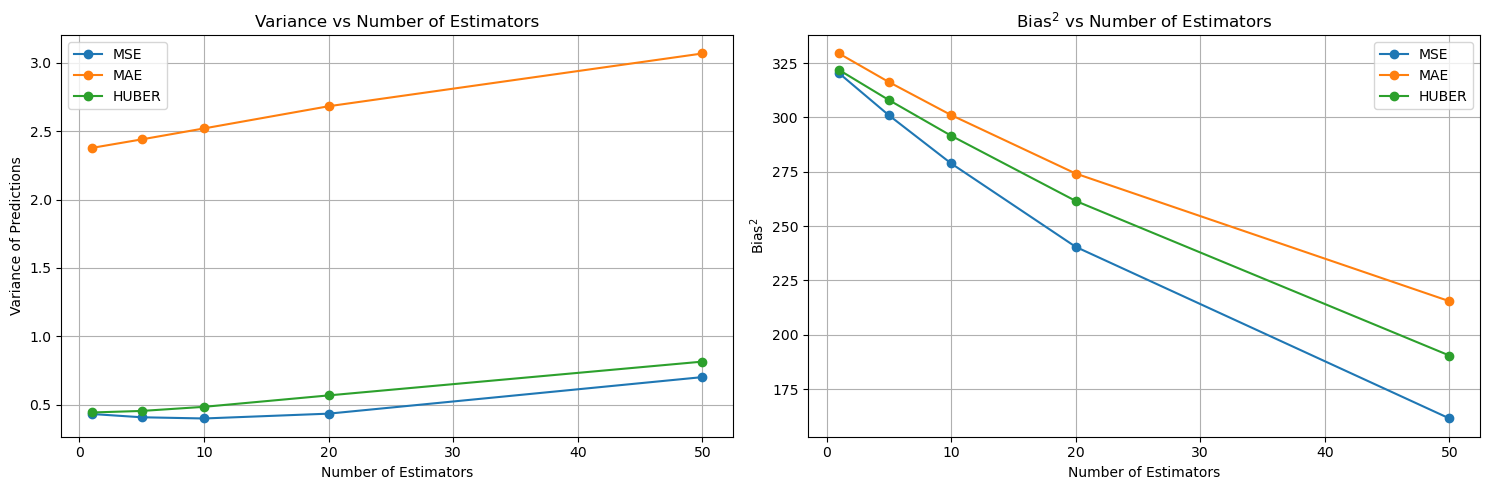

In [6]:
# Plot Variance vs n_estimators
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
for loss_name in losses.keys():
    subset = df_results[df_results["Loss"] == loss_name]
    plt.plot(subset["n_estimators"], subset["GB Variance"], marker='o', label=loss_name.upper())
plt.title("Variance vs Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Variance of Predictions")
plt.grid(True)
plt.legend()

# Plot Bias^2 vs n_estimators
plt.subplot(1,2,2)
for loss_name in losses.keys():
    subset = df_results[df_results["Loss"] == loss_name]
    plt.plot(subset["n_estimators"], subset["GB Bias^2"], marker='o', label=loss_name.upper())
plt.title(r"$\text{Bias}^2$ vs Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel(r"$\text{Bias}^2$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## 5. Observations
**Bias-Variance Tradeoff:**  
   - Initially, weak learners have **high bias** and low variance.  
   - As $n_{\text{estimators}}$ increases:
     $$
     \text{Bias}^2 \downarrow, \quad \text{Variance} \uparrow
     $$

---

## 6. Visualization

The following plots summarize the experiment:

- **Left:** Variance of GB predictions vs number of estimators  
- **Right:** Bias² of GB predictions vs number of estimators

---
